# Base 5 — ouro semanal: Random Forest direto no preço
> **Modelo auxiliar:** prevê preço diretamente para análise de sensibilidade. Não participa da comparação final entre os quatro modelos, cujo alvo canônico é `target_log_return_t_plus_1`.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import statsmodels
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller


def find_project_root(start):
    for candidate in (start, *start.parents):
        if ((candidate / 'projeto.yaml').is_file() or
                (candidate / 'config' / 'projeto.yaml').is_file()):
            return candidate
    raise FileNotFoundError('Execute a partir do projeto ou de uma subpasta dele.')


ROOT = find_project_root(Path.cwd().resolve())
SRC_PATH = ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from series_temporais.data import (
    ALVO_CANONICO,
    preparar_modelagem_ouro,
    preparar_ouro_semanal,
    selecionar_alvos_observados,
)
from series_temporais.validation import validate_prediction_contract
from series_temporais.validation.temporal_split import purged_time_series_splits


In [2]:
BASE_DIR = ROOT / 'data/base_05'
DATA_PATH = BASE_DIR / 'raw.csv'
WEEKLY_RULE = 'W-FRI'
STL_PERIOD = 52
TRAIN_RATIO = .75
RANDOM_STATE = 42
REFIT_EVERY = 1
TARGET = 'target_price_t_plus_1'
np.random.seed(RANDOM_STATE)


## 2. Ingestão e auditoria do CSV atual

Somente `DATE`, `GOLD_PRICE`, `TREASURY_10Y` e `FED_FUNDS_RATE` alimentam a
reconstrução. As derivações entregues são auditadas, mas excluídas do modelo,
pois foram calculadas em outra grade temporal.

In [3]:
expected_columns = [
    'DATE', 'GOLD_PRICE', 'TREASURY_10Y', 'FED_FUNDS_RATE', 'DAY_OF_WEEK',
    'MONTH', 'DOW_SIN', 'DOW_COS', 'MONTH_SIN', 'MONTH_COS', 'GOLD_LAG_1',
    'GOLD_LAG_5', 'GOLD_LAG_20', 'GOLD_ROLLING_MEAN_5',
    'GOLD_ROLLING_STD_5', 'TARGET',
]
derived_source_columns = expected_columns[4:]
df_raw = pd.read_csv(DATA_PATH, dtype={'DATE': 'string'})
assert df_raw.columns.tolist() == expected_columns
file_hash = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
df = df_raw.copy()
df['DATE'] = pd.to_datetime(df.DATE, format='%Y-%m-%d', errors='raise')
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors='coerce')
df = df.sort_values('DATE', kind='stable').reset_index(drop=True)
next_row_match = np.isclose(df.TARGET.iloc[:-1], df.GOLD_PRICE.shift(-1).iloc[:-1], equal_nan=False).mean()
lag_1_match = np.isclose(df.GOLD_LAG_1.iloc[1:], df.GOLD_PRICE.shift(1).iloc[1:], equal_nan=False).mean()
quality_report = pd.Series({
    'arquivo': str(DATA_PATH.relative_to(ROOT)), 'sha256': file_hash,
    'linhas': len(df), 'colunas': len(df.columns),
    'primeira_data': df.DATE.min(), 'ultima_data': df.DATE.max(),
    'datas_nulas': int(df.DATE.isna().sum()),
    'datas_duplicadas': int(df.DATE.duplicated().sum()),
    'valores_nulos': int(df.isna().sum().sum()),
    'precos_nao_positivos': int(df.GOLD_PRICE.le(0).sum()),
    'TARGET_igual_proxima_linha_fracao': next_row_match,
    'GOLD_LAG_1_igual_shift_fracao': lag_1_match,
}, name='valor').to_frame()
assert df.DATE.is_unique and df.GOLD_PRICE.gt(0).all()
display(quality_report)
display(df.head())

,valor
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
linhas,9864
colunas,16
primeira_data,1968-04-29 00:00:00
ultima_data,2014-04-09 00:00:00
datas_nulas,0
datas_duplicadas,0
valores_nulos,0
precos_nao_positivos,0


,DATE,GOLD_PRICE,TREASURY_10Y,FED_FUNDS_RATE,DAY_OF_WEEK,MONTH,DOW_SIN,DOW_COS,MONTH_SIN,MONTH_COS,GOLD_LAG_1,GOLD_LAG_5,GOLD_LAG_20,GOLD_ROLLING_MEAN_5,GOLD_ROLLING_STD_5,TARGET
0,1968-04-29,38.55,5.71,6.13,0,4,0.000000,1.000000,0.866025,-0.500000,38.50,38.30,38.0,38.29,0.163554,39.10
1,1968-04-30,39.10,5.73,6.13,1,4,0.781831,0.623490,0.866025,-0.500000,38.55,38.05,37.6,38.34,0.201246,39.10
2,1968-05-01,39.10,5.74,6.25,2,5,0.974928,-0.222521,0.500000,-0.866025,39.10,38.35,37.7,38.55,0.329773,39.25
3,1968-05-02,39.25,5.73,6.38,3,5,0.433884,-0.900969,0.500000,-0.866025,39.10,38.25,36.7,38.70,0.382426,39.60
4,1968-05-03,39.60,5.76,6.25,4,5,-0.433884,-0.900969,0.500000,-0.866025,39.25,38.50,37.2,38.90,0.348210,39.70


## 3. Limpeza e preparação semanal causal

Cada sexta-feira representa a origem semanal. Em semanas vazias, somente o
último estado já conhecido é carregado para frente; data da última cotação,
idade e indicador de carregamento permanecem explícitos.

In [4]:
weekly = preparar_ouro_semanal(df, WEEKLY_RULE)
weekly_quality = pd.Series({
    'semanas': len(weekly), 'primeira_semana': weekly.DATE.min(),
    'ultima_semana': weekly.DATE.max(),
    'semanas_sem_linha_de_origem': int(weekly.price_was_carried.sum()),
    'maior_idade_da_cotacao_em_dias': int(weekly.quote_age_days.max()),
    'menor_preco': weekly.price_t.min(), 'maior_preco': weekly.price_t.max(),
    'min_observacoes_por_semana': int(weekly.source_observations.min()),
    'max_observacoes_por_semana': int(weekly.source_observations.max()),
}, name='valor').to_frame()
assert weekly.DATE.diff().dropna().dt.days.eq(7).all()
display(weekly_quality)
display(weekly.head())

,valor
semanas,2398
primeira_semana,1968-05-03 00:00:00
ultima_semana,2014-04-11 00:00:00
semanas_sem_linha_de_origem,254
maior_idade_da_cotacao_em_dias,17
menor_preco,34.775
maior_preco,1879.5
min_observacoes_por_semana,0
max_observacoes_por_semana,5


,DATE,price_t,treasury_10y_t,fed_funds_rate_t,source_observations,last_quote_date,price_was_carried,quote_age_days,log_price_t,log_return_t
0,1968-05-03,39.60,5.76,6.25,5,1968-05-03,False,0,3.678829,NaN
1,1968-05-10,39.70,5.80,5.50,4,1968-05-09,False,1,3.681351,0.002522
2,1968-05-17,41.60,5.90,6.38,4,1968-05-17,False,0,3.728100,0.046749
3,1968-05-24,41.75,5.98,6.25,5,1968-05-24,False,0,3.731699,0.003599
4,1968-05-31,41.75,5.95,5.75,4,1968-05-30,False,1,3.731699,0.000000


## 4. Gráficos exploratórios

Os gráficos preservam picos e tornam visíveis retorno, taxas, volatilidade e
cobertura. Nenhuma observação é removida por parecer extrema.

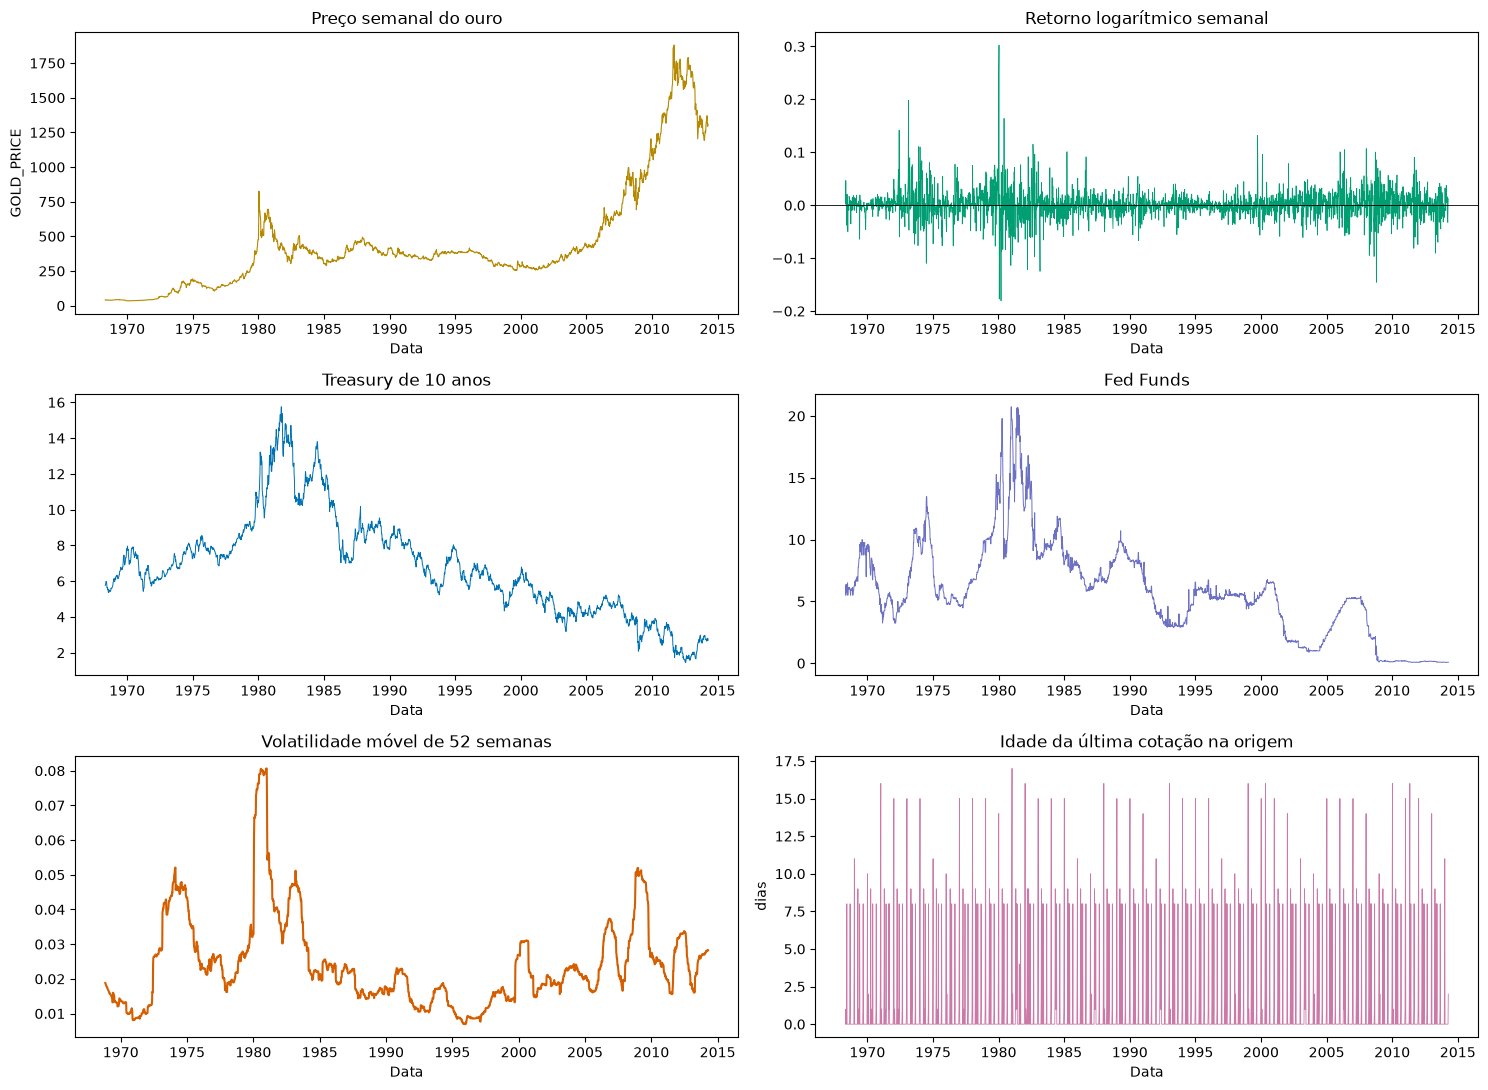

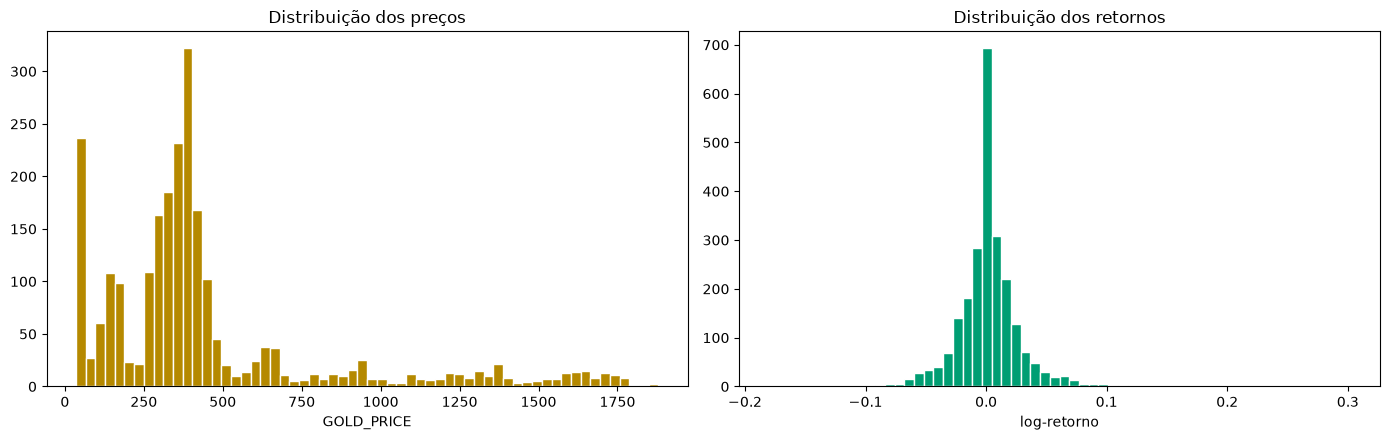

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(15, 11))
axes[0, 0].plot(weekly.DATE, weekly.price_t, lw=.8, color='#b58900')
axes[0, 0].set(title='Preço semanal do ouro', ylabel='GOLD_PRICE')
axes[0, 1].plot(weekly.DATE, weekly.log_return_t, lw=.55, color='#009e73')
axes[0, 1].axhline(0, color='black', lw=.6); axes[0, 1].set(title='Retorno logarítmico semanal')
axes[1, 0].plot(weekly.DATE, weekly.treasury_10y_t, lw=.7, color='#0072b2')
axes[1, 0].set(title='Treasury de 10 anos')
axes[1, 1].plot(weekly.DATE, weekly.fed_funds_rate_t, lw=.7, color='#6c71c4')
axes[1, 1].set(title='Fed Funds')
axes[2, 0].plot(weekly.DATE, weekly.log_return_t.rolling(52, min_periods=26).std(), color='#d55e00')
axes[2, 0].set(title='Volatilidade móvel de 52 semanas')
axes[2, 1].plot(weekly.DATE, weekly.quote_age_days, lw=.6, color='#cc79a7')
axes[2, 1].set(title='Idade da última cotação na origem', ylabel='dias')
for ax in axes.flat: ax.set_xlabel('Data')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(weekly.price_t, bins=60, edgecolor='white', color='#b58900')
axes[0].set(title='Distribuição dos preços', xlabel='GOLD_PRICE')
axes[1].hist(weekly.log_return_t.dropna(), bins=60, edgecolor='white', color='#009e73')
axes[1].set(title='Distribuição dos retornos', xlabel='log-retorno')
plt.tight_layout(); plt.show()

## 5. STL e força da sazonalidade

A STL robusta usa apenas os 75% iniciais da série semanal. A força sazonal é
`max(0, 1 - Var(R) / Var(S + R))`; a força da tendência usa fórmula análoga.

,componente,forca,periodo_stl
0,sazonalidade,0.000000,52
1,tendência,0.927517,52


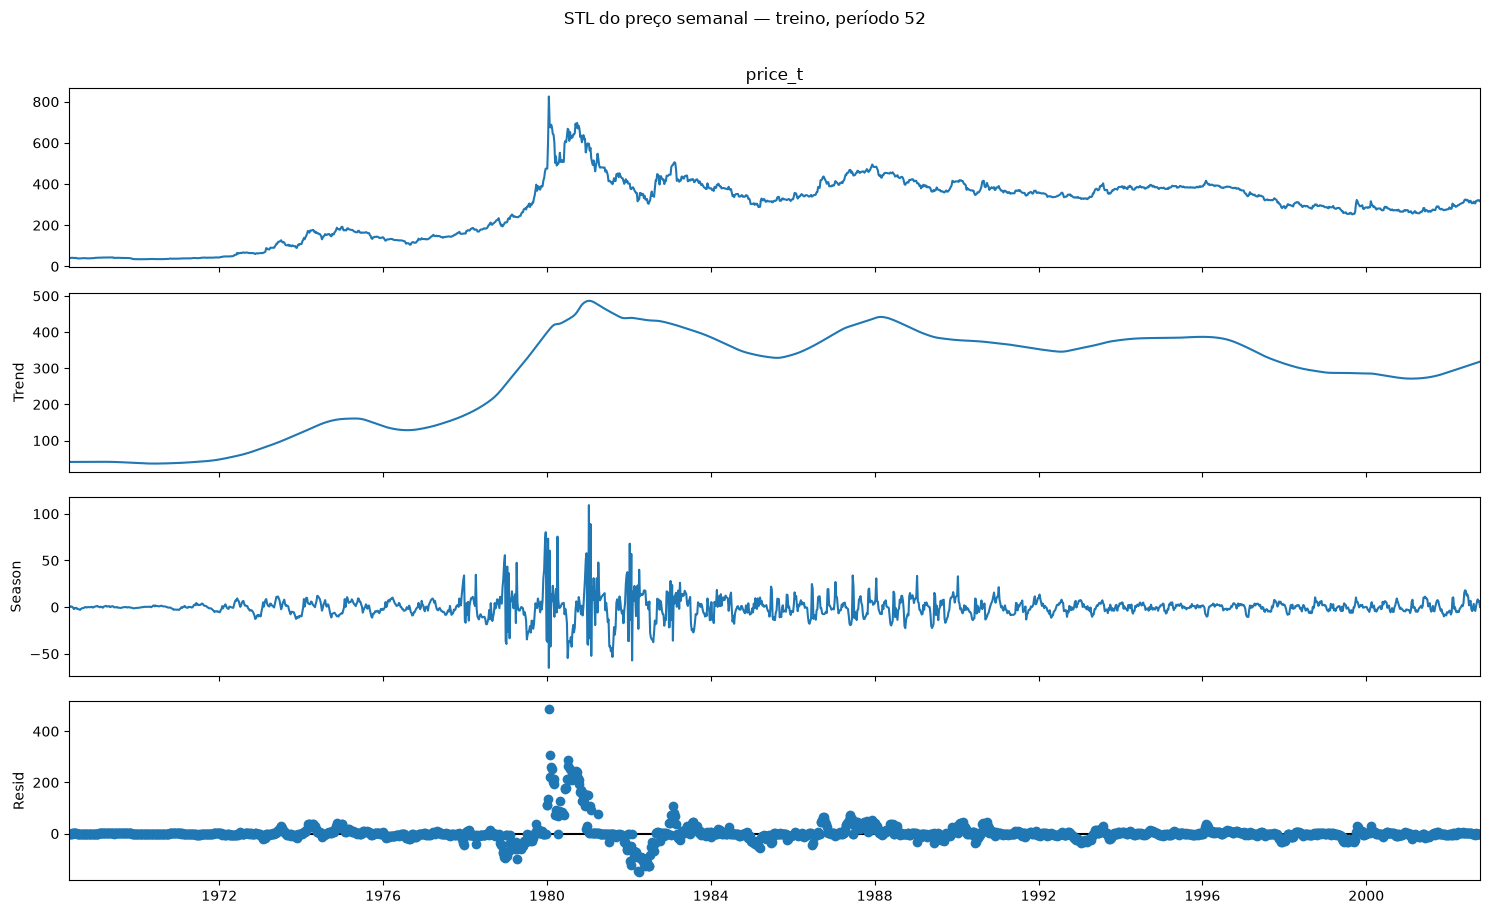

Interpretação: força sazonal 0.000 e força de tendência 0.928. A tendência apresenta crescimento líquido de 277.43 unidades no treino. O resíduo concentra variação não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.


In [6]:
stl_cut = int(len(weekly) * TRAIN_RATIO)
stl_series = weekly.iloc[:stl_cut].set_index('DATE').price_t.asfreq(WEEKLY_RULE)
assert stl_series.notna().all() and len(stl_series) >= 2 * STL_PERIOD
stl_result = STL(stl_series, period=STL_PERIOD, robust=True).fit()
resid_var = np.var(stl_result.resid, ddof=1)
seasonal_strength = max(0., 1. - resid_var / np.var(stl_result.seasonal + stl_result.resid, ddof=1))
trend_strength = max(0., 1. - resid_var / np.var(stl_result.trend + stl_result.resid, ddof=1))
display(pd.DataFrame({
    'componente': ['sazonalidade', 'tendência'],
    'forca': [seasonal_strength, trend_strength], 'periodo_stl': STL_PERIOD,
}))
fig = stl_result.plot(); fig.set_size_inches(15, 9)
fig.suptitle('STL do preço semanal — treino, período 52', y=1.01)
plt.tight_layout(); plt.show()
trend_change = float(stl_result.trend.iloc[-1] - stl_result.trend.iloc[0])
trend_direction = 'crescimento' if trend_change > 0 else 'queda' if trend_change < 0 else 'estabilidade'
print(
    f'Interpretação: força sazonal {seasonal_strength:.3f} e força de tendência '
    f'{trend_strength:.3f}. A tendência apresenta {trend_direction} líquido de '
    f'{abs(trend_change):.2f} unidades no treino. O resíduo concentra variação '
    'não explicada pelos componentes; mudanças locais devem ser lidas no gráfico.'
)

## 6. Features, corte temporal, ADF, ACF e PACF

Lags e janelas são reconstruídos depois da agregação semanal. Datas-alvo,
preço futuro e todas as derivações entregues no CSV ficam fora de `X`. Neste
notebook, o alvo de treinamento é diretamente o preço da semana seguinte,
`target_price_t_plus_1`.
Somente semanas-alvo com cotação nova entram no tuning e no ajuste. O indicador de disponibilidade do alvo nunca entra em `X`.


,recorte,linhas,inicio_origem,fim_origem
0,treino — grade,1758,1969-05-09,2003-01-10
1,treino — alvos observados,1571,1969-05-09,2003-01-10
2,teste — grade,586,2003-01-17,2014-04-04


C:\Users\matheuscastilho-ieg\AppData\Local\Temp\ipykernel_2700\2043214433.py:14: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')
C:\Users\matheuscastilho-ieg\AppData\Local\Temp\ipykernel_2700\2043214433.py:14: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna(), autolag='AIC')


,serie,estatistica,p_valor,lags
0,log do preço semanal — treino,-2.501483,1.151139e-01,8
1,retorno log semanal — treino,-14.194482,1.832578e-26,7


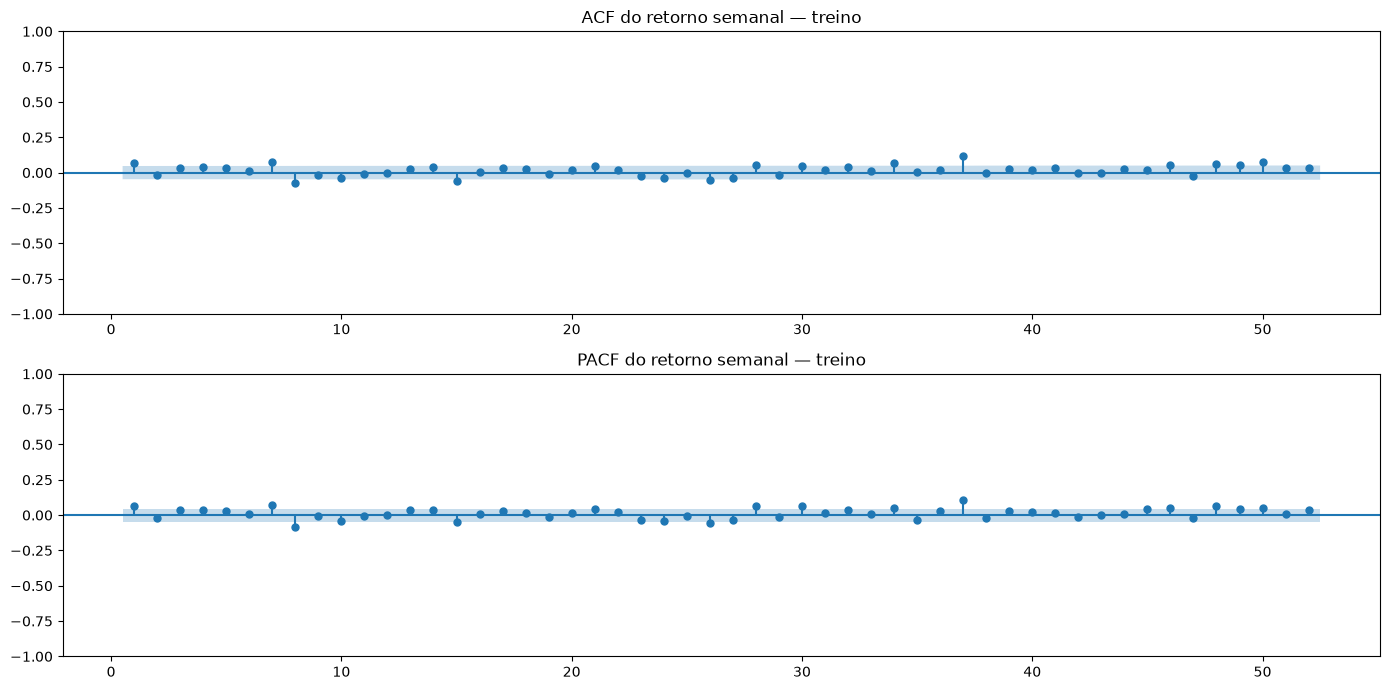

In [7]:
weekly, model_df, feature_columns, train_df, test_df = preparar_modelagem_ouro(
    df, regra_semanal=WEEKLY_RULE, proporcao_treino=TRAIN_RATIO,
)
training_df = selecionar_alvos_observados(train_df)
X_train, y_train = training_df[feature_columns], training_df[TARGET]
X_test, y_test = test_df[feature_columns], test_df[TARGET]
assert len(train_df) == 1758 and len(test_df) == 586
assert train_df.target_date.max() <= test_df.DATE.min()
assert not set(derived_source_columns).intersection(feature_columns)
assert 'target_has_new_quote' not in feature_columns
assert training_df.target_has_new_quote.eq(1).all()

def adf_row(name, series):
    result = adfuller(series.dropna(), autolag='AIC')
    return {'serie': name, 'estatistica': result[0], 'p_valor': result[1], 'lags': result[2]}
display(pd.DataFrame({
    'recorte': ['treino — grade', 'treino — alvos observados', 'teste — grade'],
    'linhas': [len(train_df), len(training_df), len(test_df)],
    'inicio_origem': [train_df.DATE.min(), training_df.DATE.min(), test_df.DATE.min()],
    'fim_origem': [train_df.DATE.max(), training_df.DATE.max(), test_df.DATE.max()],
}))
display(pd.DataFrame([
    adf_row('log do preço semanal — treino', train_df.log_price_t),
    adf_row('retorno log semanal — treino', train_df.log_return_t),
]))
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
plot_acf(train_df.log_return_t, lags=52, zero=False, ax=axes[0])
plot_pacf(train_df.log_return_t, lags=52, zero=False, method='ywm', ax=axes[1])
axes[0].set_title('ACF do retorno semanal — treino')
axes[1].set_title('PACF do retorno semanal — treino')
plt.tight_layout(); plt.show()


## 7. Otimização temporal do Random Forest

O desenho investiga explicitamente `n_estimators`, `max_depth`,
`min_samples_split`, `min_samples_leaf` e `max_features` em três dobras
expansivas purgadas. A seleção minimiza o MAE do preço e o teste final não
participa da escolha.

In [8]:
candidates = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': 12, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'},
    {'n_estimators': 100, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': .7},
    {'n_estimators': 250, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': .7},
]
cv_splits = purged_time_series_splits(training_df.DATE, training_df.target_date, n_splits=3)
search_rows = []
search_start = time.perf_counter()
for candidate_id, params in enumerate(candidates, start=1):
    fold_maes, fold_seconds = [], []
    for fold, (fit_idx, validation_idx) in enumerate(cv_splits, start=1):
        candidate = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        fold_start = time.perf_counter()
        candidate.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        prediction = candidate.predict(X_train.iloc[validation_idx])
        fold_seconds.append(time.perf_counter() - fold_start)
        fold_maes.append(mean_absolute_error(y_train.iloc[validation_idx], prediction))
    search_rows.append({
        'candidate_id': candidate_id, **params,
        'mean_validation_mae': np.mean(fold_maes),
        'std_validation_mae': np.std(fold_maes, ddof=1),
        'fit_seconds': np.sum(fold_seconds),
    })
search_seconds = time.perf_counter() - search_start
search_results = pd.DataFrame(search_rows).sort_values(
    ['mean_validation_mae', 'std_validation_mae', 'candidate_id']
).reset_index(drop=True)
best_params = {key: search_results.iloc[0][key] for key in candidates[0]}
for key in ('n_estimators', 'min_samples_split', 'min_samples_leaf'):
    best_params[key] = int(best_params[key])
best_params['max_depth'] = None if pd.isna(best_params['max_depth']) else int(best_params['max_depth'])
display(search_results)
print('Melhores parâmetros:', best_params)
print(f'Tempo de busca: {search_seconds:.2f} s')

,candidate_id,n_estimators,max_depth,min_samples_split,min_samples_leaf,max_features,mean_validation_mae,std_validation_mae,fit_seconds
0,8,250,6.0,10,3,0.7,71.518826,107.525290,2.444124
1,7,100,NaN,2,1,0.7,71.783506,107.165925,1.392802
2,9,250,12.0,5,2,0.7,71.822922,107.590708,2.611210
3,2,250,NaN,2,1,sqrt,81.180285,105.011880,1.987780
4,1,100,NaN,2,1,sqrt,82.083374,104.123532,0.900197
5,4,100,12.0,10,1,sqrt,83.430372,103.243222,0.828896
6,5,100,NaN,2,3,sqrt,83.513082,102.648136,0.799868
7,6,250,6.0,2,3,sqrt,84.027002,103.101294,1.893059
8,3,100,6.0,2,1,sqrt,84.858006,102.277894,0.795421


Melhores parâmetros: {'n_estimators': 250, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 0.7}
Tempo de busca: 13.73 s


## 8. Walk-forward final e importância das features

Os parâmetros permanecem fixos. O modelo é reajustado em cada origem de teste.
Cada ajuste usa somente alvos já revelados e com cotação nova, mas todas as 586
origens recebem uma previsão fora da amostra.


,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,has_source_observation_t,price_pred_rf,model_refit_origin,training_target_cutoff,price_pred_persistence,y_pred_return_rf,y_pred_return_zero,residual_price_rf,absolute_error_price_rf,residual_return_rf
1758,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,1,356.490913,2003-01-17,2003-01-17,358.20,-0.004783,0.0,7.609087,7.609087,0.021120
1759,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,1,365.610300,2003-01-24,2003-01-24,364.10,0.004139,0.0,4.739700,4.739700,0.012880
1760,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,1,370.695188,2003-01-31,2003-01-31,370.35,0.000932,0.0,-0.145188,0.145188,-0.000392
1761,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,1,371.026453,2003-02-07,2003-02-07,370.55,0.001285,0.0,-14.776453,14.776453,-0.040641
1762,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,1,355.175696,2003-02-14,2003-02-14,356.25,-0.003020,0.0,-1.175696,1.175696,-0.003316


,feature,importance_mean,importance_std,grupo
0,log_price_t,0.316992,0.080330,historico_ou_cobertura
1,price_t,0.288821,0.065274,historico_ou_cobertura
2,price_mean_52,0.096783,0.065139,historico_ou_cobertura
3,price_mean_26,0.092554,0.053934,historico_ou_cobertura
4,price_lag_1,0.069351,0.016484,historico_ou_cobertura
5,price_mean_4,0.042507,0.021156,historico_ou_cobertura
6,price_mean_13,0.041269,0.034362,historico_ou_cobertura
7,price_lag_13,0.024093,0.028243,historico_ou_cobertura
8,price_lag_26,0.016353,0.018098,historico_ou_cobertura
9,price_lag_4,0.006542,0.004212,historico_ou_cobertura


,grupo,importance_mean
0,calendario,0.000352
1,externa_na_origem,0.001041
2,historico_ou_cobertura,0.998607


Externas mais importantes (importância nativa, não causal):


,feature,importance_mean,importance_std,grupo
13,treasury_10y_t,0.000227,0.000379,externa_na_origem
16,fed_funds_rate_t,0.000160,0.000111,externa_na_origem
17,treasury_lag_13,0.000159,0.000079,externa_na_origem
19,fed_funds_lag_1,0.000148,0.000130,externa_na_origem
22,treasury_lag_1,0.000098,0.000096,externa_na_origem
23,fed_funds_lag_4,0.000093,0.000072,externa_na_origem
29,treasury_lag_4,0.000067,0.000047,externa_na_origem
32,fed_funds_lag_13,0.000054,0.000072,externa_na_origem


Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; nenhuma taxa observada da semana-alvo entra em X.


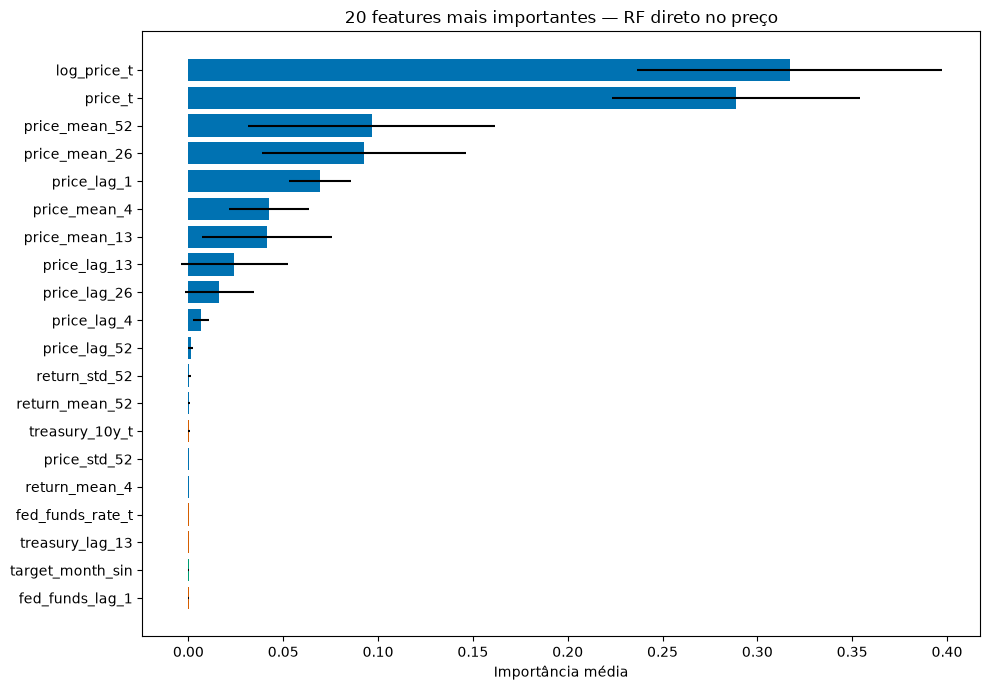

In [9]:
prediction_values, prediction_refits, training_cutoffs = [], [], []
fit_rows, importance_rows = [], []
evaluation_start = time.perf_counter()
for block_start in range(0, len(test_df), REFIT_EVERY):
    block_end = min(block_start + REFIT_EVERY, len(test_df))
    current_origin = test_df.iloc[block_start].DATE
    known_test = test_df.target_date <= current_origin
    history_all = pd.concat([train_df, test_df.loc[known_test]], ignore_index=True)
    history = selecionar_alvos_observados(history_all)
    assert history.target_has_new_quote.eq(1).all()
    model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    fit_start = time.perf_counter()
    model.fit(history[feature_columns], history[TARGET])
    prediction_values.extend(model.predict(X_test.iloc[block_start:block_end]))
    prediction_refits.extend([current_origin] * (block_end - block_start))
    training_cutoff = history.target_date.max()
    training_cutoffs.extend([training_cutoff] * (block_end - block_start))
    fit_rows.append({
        'origem_refit': current_origin, 'linhas_historico_revelado': len(history_all),
        'linhas_alvos_observados': len(history),
        'inicio_bloco': block_start, 'fim_bloco_exclusivo': block_end,
        'fit_seconds': time.perf_counter() - fit_start,
    })
    importance_rows.append(model.feature_importances_)
evaluation_seconds = time.perf_counter() - evaluation_start

predictions = test_df[[
    'DATE', 'target_date', 'price_t', 'target_price_t_plus_1',
    'target_log_return_t_plus_1', 'target_has_new_quote', 'has_source_observation_t',
]].copy()
predictions = predictions.rename(columns={'target_log_return_t_plus_1': 'y_true_return'})
predictions['price_pred_rf'] = np.asarray(prediction_values)
predictions['model_refit_origin'] = prediction_refits
predictions['training_target_cutoff'] = training_cutoffs
assert (predictions.training_target_cutoff <= predictions.DATE).all()
predictions['price_pred_persistence'] = predictions.price_t
predictions['y_pred_return_rf'] = np.log(predictions.price_pred_rf / predictions.price_t)
predictions['y_pred_return_zero'] = 0.
predictions['residual_price_rf'] = predictions.target_price_t_plus_1 - predictions.price_pred_rf
predictions['absolute_error_price_rf'] = predictions.residual_price_rf.abs()
observed_predictions = predictions.loc[predictions.target_has_new_quote.eq(1)].copy()
predictions['residual_return_rf'] = predictions.y_true_return - predictions.y_pred_return_rf

contract_predictions = pd.DataFrame({
    'origin_time': predictions.DATE,
    'target_time': predictions.target_date,
    'y_true': predictions.target_price_t_plus_1,
    'y_pred': predictions.price_pred_rf,
    'training_target_cutoff': predictions.training_target_cutoff,
})
validate_prediction_contract(
    contract_predictions, test_df, expected_target_col='target_price_t_plus_1',
)

fit_log = pd.DataFrame(fit_rows)
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance_mean': np.mean(importance_rows, axis=0),
    'importance_std': np.std(importance_rows, axis=0),
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)
external_prefixes = ('treasury_', 'fed_funds_')
feature_importance['grupo'] = np.select(
    [feature_importance.feature.str.startswith(external_prefixes),
     feature_importance.feature.str.startswith(('price_', 'return_', 'log_', 'source_', 'quote_', 'weeks_'))],
    ['externa_na_origem', 'historico_ou_cobertura'], default='calendario',
)
display(predictions.head())
display(feature_importance.head(20))
display(feature_importance.groupby('grupo', as_index=False).importance_mean.sum())
print('Externas mais importantes (importância nativa, não causal):')
display(feature_importance.loc[feature_importance.grupo.eq('externa_na_origem')].head(8))
print(
    'Disponibilidade: taxas no estado conhecido até a sexta-feira de origem; '
    'nenhuma taxa observada da semana-alvo entra em X.'
)
fig, ax = plt.subplots(figsize=(10, 7))
top = feature_importance.head(20).sort_values('importance_mean')
palette = {'externa_na_origem': '#d55e00', 'historico_ou_cobertura': '#0072b2', 'calendario': '#009e73'}
ax.barh(top.feature, top.importance_mean, xerr=top.importance_std,
        color=top.grupo.map(palette))
ax.set(title='20 features mais importantes — RF direto no preço', xlabel='Importância média')
plt.tight_layout(); plt.show()


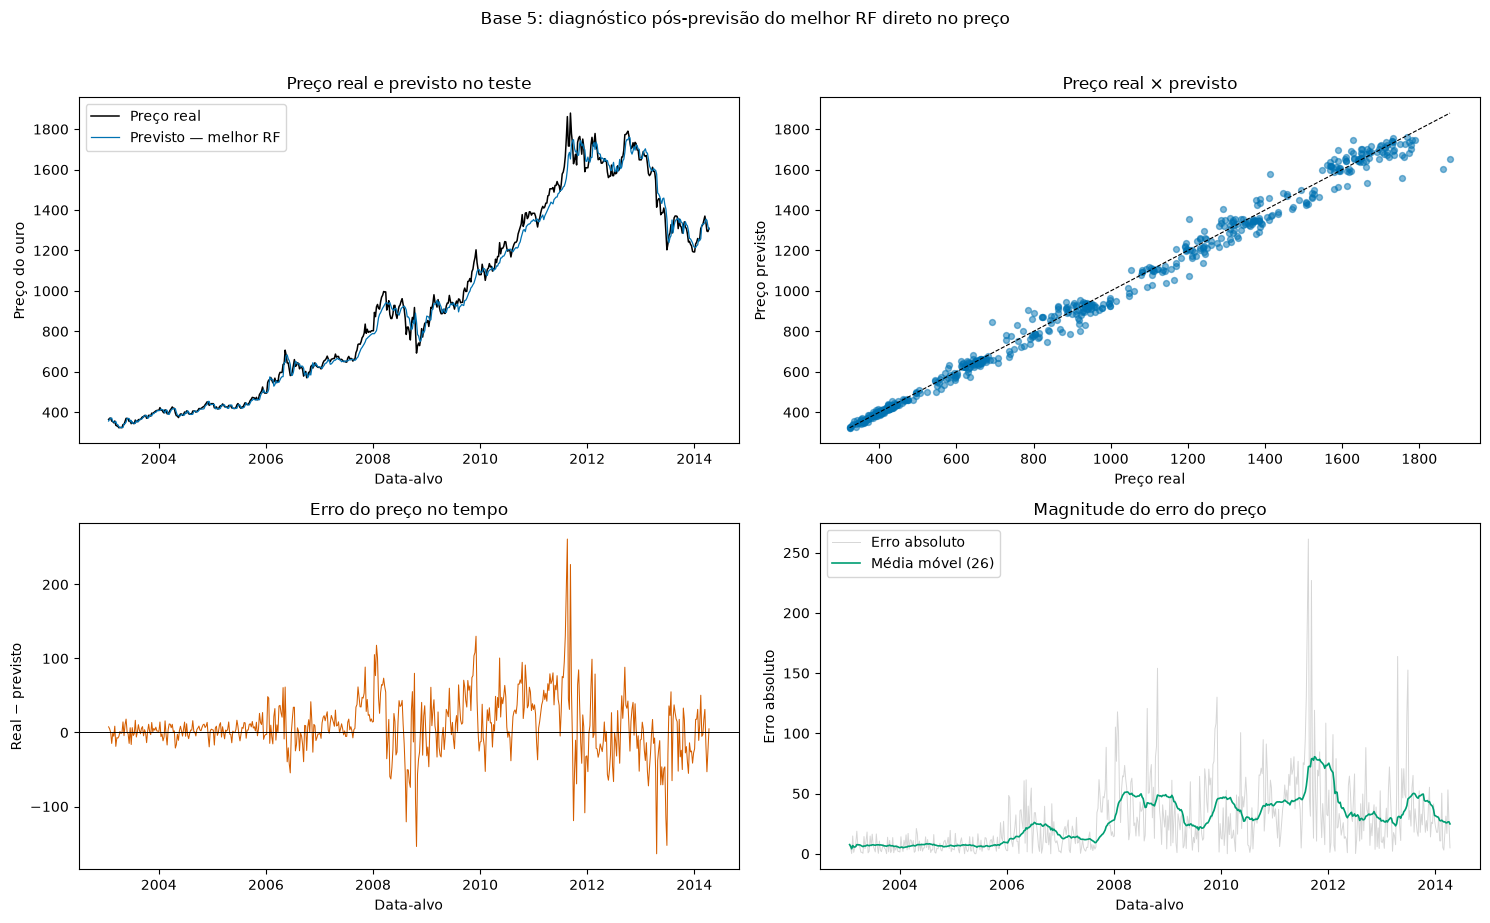

In [10]:
# Diagnóstico visual fora da amostra do melhor Random Forest direto no preço
diagnostic_window = min(26, max(5, len(predictions) // 10))
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

axes[0, 0].plot(predictions.target_date, predictions.target_price_t_plus_1, label='Preço real', color='black', lw=1.1)
axes[0, 0].plot(predictions.target_date, predictions.price_pred_rf, label='Previsto — melhor RF', color='#0072b2', lw=.9)
axes[0, 0].set(title='Preço real e previsto no teste', xlabel='Data-alvo', ylabel='Preço do ouro')
axes[0, 0].legend()

plot_limits = [predictions[['target_price_t_plus_1', 'price_pred_rf']].min().min(), predictions[['target_price_t_plus_1', 'price_pred_rf']].max().max()]
axes[0, 1].scatter(predictions.target_price_t_plus_1, predictions.price_pred_rf, s=18, alpha=.5, color='#0072b2')
axes[0, 1].plot(plot_limits, plot_limits, '--', color='black', lw=.8)
axes[0, 1].set(title='Preço real × previsto', xlabel='Preço real', ylabel='Preço previsto')

axes[1, 0].plot(predictions.target_date, predictions.residual_price_rf, color='#d55e00', lw=.75)
axes[1, 0].axhline(0, color='black', lw=.7)
axes[1, 0].set(title='Erro do preço no tempo', xlabel='Data-alvo', ylabel='Real − previsto')

axes[1, 1].plot(predictions.target_date, predictions.absolute_error_price_rf, color='#999999', alpha=.4, lw=.7, label='Erro absoluto')
axes[1, 1].plot(predictions.target_date, predictions.absolute_error_price_rf.rolling(diagnostic_window, min_periods=1).mean(), color='#009e73', lw=1.2, label=f'Média móvel ({diagnostic_window})')
axes[1, 1].set(title='Magnitude do erro do preço', xlabel='Data-alvo', ylabel='Erro absoluto')
axes[1, 1].legend()

fig.suptitle('Base 5: diagnóstico pós-previsão do melhor RF direto no preço', y=1.02)
plt.tight_layout(); plt.show()

## 9. MAE e demais métricas do preço
A avaliação principal usa semanas-alvo com cotação nova. A grade completa é apresentada somente como sensibilidade; o recorte com cotação na origem e no alvo é uma robustez adicional.


In [11]:
def metric_row(name, price_prediction, subset=None):
    mask = pd.Series(True, index=predictions.index) if subset is None else subset
    actual_price = predictions.loc[mask, 'target_price_t_plus_1']
    predicted_price = np.asarray(price_prediction)[mask.to_numpy()]
    origin_price = predictions.loc[mask, 'price_t']
    actual_up = actual_price.to_numpy() > origin_price.to_numpy()
    predicted_up = predicted_price > origin_price.to_numpy()
    return {
        'modelo': name,
        'observacoes': int(mask.sum()),
        'MAE_preco': mean_absolute_error(actual_price, predicted_price),
        'RMSE_preco': mean_squared_error(actual_price, predicted_price) ** .5,
        'MedAE_preco': median_absolute_error(actual_price, predicted_price),
        'MAPE_preco_pct': np.mean(np.abs((actual_price - predicted_price) / actual_price)) * 100,
        'R2_preco': r2_score(actual_price, predicted_price),
        'vies_preco_real_menos_previsto': np.mean(actual_price - predicted_price),
        'acuracia_direcional': np.mean(actual_up == predicted_up),
    }


new_quote = predictions.target_has_new_quote.eq(1)
origin_and_target_quote = predictions.has_source_observation_t.eq(1) & new_quote
metrics = pd.DataFrame([
    metric_row('Random Forest direto — nova cotação', predictions.price_pred_rf, new_quote),
    metric_row('Persistência — nova cotação', predictions.price_pred_persistence, new_quote),
    metric_row('Random Forest direto — origem e alvo com cotação', predictions.price_pred_rf, origin_and_target_quote),
    metric_row('Persistência — origem e alvo com cotação', predictions.price_pred_persistence, origin_and_target_quote),
    metric_row('Random Forest direto — todas (sensibilidade)', predictions.price_pred_rf),
    metric_row('Persistência — todas (sensibilidade)', predictions.price_pred_persistence),
])
metrics['skill_mae_preco_vs_persistencia'] = np.nan
for suffix in ('nova cotação', 'origem e alvo com cotação', 'todas (sensibilidade)'):
    baseline_mae = metrics.loc[metrics.modelo.eq(f'Persistência — {suffix}'), 'MAE_preco'].iloc[0]
    scope = metrics.modelo.str.endswith(suffix)
    metrics.loc[scope, 'skill_mae_preco_vs_persistencia'] = 1 - metrics.loc[scope, 'MAE_preco'] / baseline_mae
display(metrics)


,modelo,observacoes,MAE_preco,RMSE_preco,MedAE_preco,MAPE_preco_pct,R2_preco,vies_preco_real_menos_previsto,acuracia_direcional,skill_mae_preco_vs_persistencia
0,Random Forest direto — nova cotação,523,29.118025,42.689218,18.096007,2.978119,0.991310,9.635470,0.466539,-0.371235
1,Persistência — nova cotação,523,21.234895,31.029890,14.000000,2.251740,0.995409,1.819407,0.424474,0.000000
2,Random Forest direto — origem e alvo com cotação,469,28.352465,41.563385,17.837841,2.888473,0.991770,8.996890,0.456290,-0.405575
3,Persistência — origem e alvo com cotação,469,20.171429,29.479821,13.500000,2.122434,0.995860,0.674414,0.428571,0.000000
4,Random Forest direto — todas (sensibilidade),586,27.924083,41.230728,17.695033,2.838791,0.991876,8.865254,0.472696,-0.473414
5,Persistência — todas (sensibilidade),586,18.951962,29.314486,12.250000,2.009659,0.995893,1.623805,0.486348,0.000000


## 10. Registro de parâmetros, versões e tempo

O registro reúne hash, configuração, features, parâmetros, versões, tempos e
cada reajuste do teste para reprodução completa.

In [12]:
experiment_record = pd.DataFrame([{
    'base': 'Base 5 — ouro semanal', 'arquivo': str(DATA_PATH.relative_to(ROOT)),
    'sha256': file_hash, 'frequencia': WEEKLY_RULE,
    'alvo': TARGET, 'horizonte_provisorio': '1 semana',
    'split_treino': TRAIN_RATIO, 'random_state': RANDOM_STATE,
    'linhas_treino_grade': len(train_df), 'linhas_treino_alvo_observado': len(training_df),
    'linhas_teste': len(test_df), 'linhas_teste_alvo_observado': int(test_df.target_has_new_quote.sum()),
    'linhas_teste_origem_e_alvo_observados': int((test_df.has_source_observation_t.eq(1) & test_df.target_has_new_quote.eq(1)).sum()),
    'origem_teste_inicial': test_df.DATE.min(), 'origem_teste_final': test_df.DATE.max(),
    'numero_features': len(feature_columns),
    'features': json.dumps(feature_columns, ensure_ascii=False),
    'candidatos_tuning': len(candidates), 'dobras_validacao': len(cv_splits),
    'melhores_parametros': json.dumps(best_params, ensure_ascii=False),
    'tempo_busca_s': search_seconds, 'tempo_walk_forward_s': evaluation_seconds,
    'numero_refits_teste': len(fit_log), 'python': platform.python_version(),
    'pandas': pd.__version__, 'numpy': np.__version__,
    'scikit_learn': sklearn.__version__, 'statsmodels': statsmodels.__version__,
}])
display(experiment_record.T)
display(fit_log)

,0
base,Base 5 — ouro semanal
arquivo,data\base_05\raw.csv
sha256,c852759b32f534918f76f9c3a31342228bf0bbc8a61fc5...
frequencia,W-FRI
alvo,target_price_t_plus_1
horizonte_provisorio,1 semana
split_treino,0.75
random_state,42
linhas_treino_grade,1758
linhas_treino_alvo_observado,1571


,origem_refit,linhas_historico_revelado,linhas_alvos_observados,inicio_bloco,fim_bloco_exclusivo,fit_seconds
0,2003-01-17,1758,1571,0,1,0.982439
1,2003-01-24,1759,1572,1,2,1.180142
2,2003-01-31,1760,1573,2,3,1.074216
3,2003-02-07,1761,1574,3,4,1.306454
4,2003-02-14,1762,1575,4,5,1.026671
...,...,...,...,...,...,...
581,2014-03-07,2339,2089,581,582,1.200915
582,2014-03-14,2340,2090,582,583,1.216079
583,2014-03-21,2341,2091,583,584,1.225068
584,2014-03-28,2342,2092,584,585,1.235644


## 11. Resíduos individuais do preço
Os diagnósticos residuais usam somente semanas-alvo com cotação efetivamente observada.


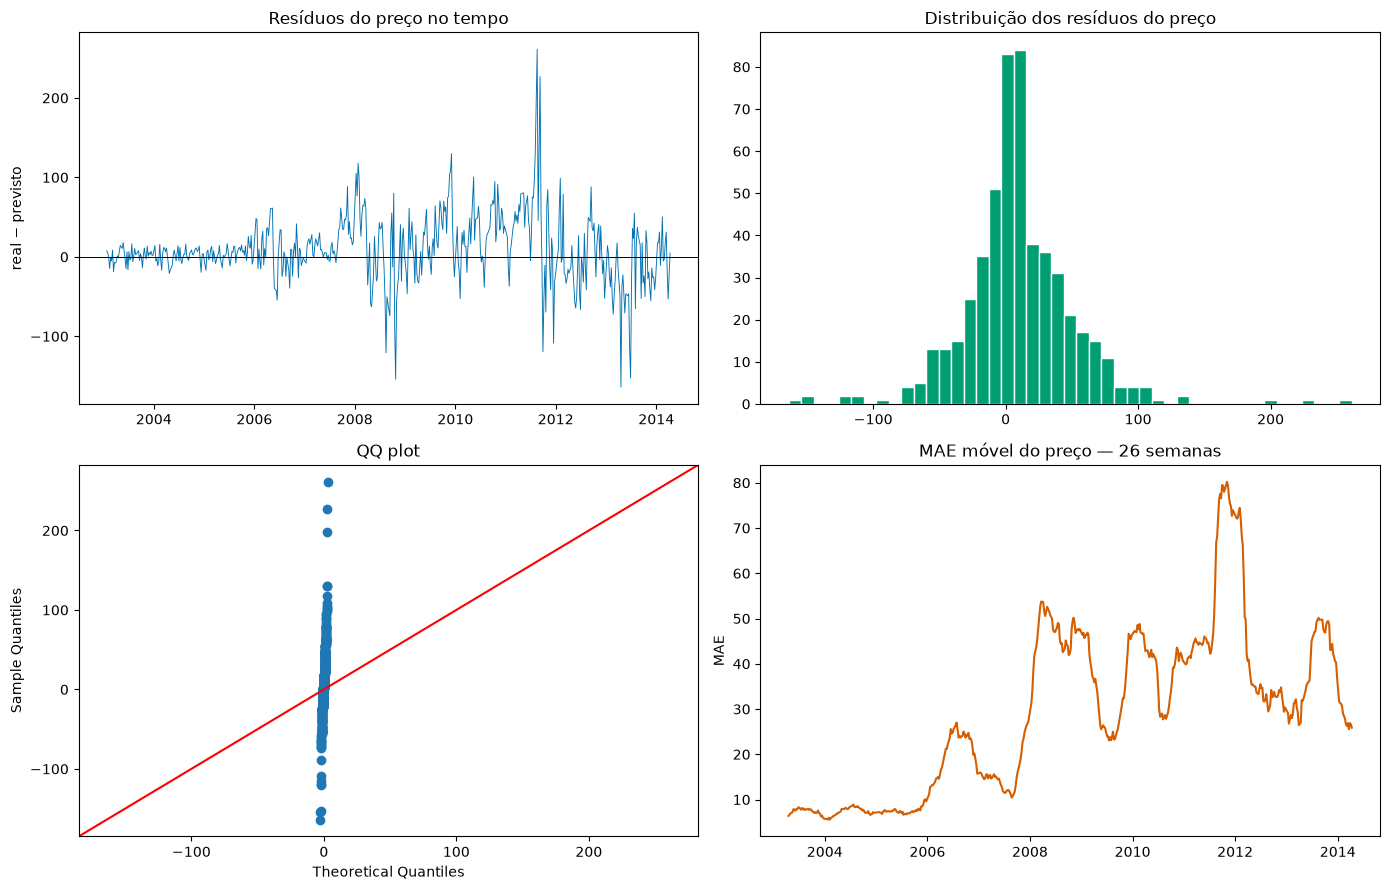

,DATE,target_date,price_t,target_price_t_plus_1,y_true_return,target_has_new_quote,has_source_observation_t,price_pred_rf,model_refit_origin,training_target_cutoff,price_pred_persistence,y_pred_return_rf,y_pred_return_zero,residual_price_rf,absolute_error_price_rf,residual_return_rf
1758,2003-01-17,2003-01-24,358.20,364.10,0.016337,1,1,356.490913,2003-01-17,2003-01-17,358.20,-0.004783,0.0,7.609087,7.609087,0.021120
1759,2003-01-24,2003-01-31,364.10,370.35,0.017020,1,1,365.610300,2003-01-24,2003-01-24,364.10,0.004139,0.0,4.739700,4.739700,0.012880
1760,2003-01-31,2003-02-07,370.35,370.55,0.000540,1,1,370.695188,2003-01-31,2003-01-31,370.35,0.000932,0.0,-0.145188,0.145188,-0.000392
1761,2003-02-07,2003-02-14,370.55,356.25,-0.039356,1,1,371.026453,2003-02-07,2003-02-07,370.55,0.001285,0.0,-14.776453,14.776453,-0.040641
1762,2003-02-14,2003-02-21,356.25,354.00,-0.006336,1,1,355.175696,2003-02-14,2003-02-14,356.25,-0.003020,0.0,-1.175696,1.175696,-0.003316
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2339,2014-03-07,2014-03-14,1348.25,1370.00,0.016003,1,1,1338.765674,2014-03-07,2014-03-07,1348.25,-0.007059,0.0,31.234326,31.234326,0.023063
2340,2014-03-14,2014-03-21,1370.00,1338.50,-0.023261,1,1,1355.393233,2014-03-14,2014-03-14,1370.00,-0.010719,0.0,-16.893233,16.893233,-0.012542
2341,2014-03-21,2014-03-28,1338.50,1295.75,-0.032460,1,1,1348.803339,2014-03-21,2014-03-21,1338.50,0.007668,0.0,-53.053339,53.053339,-0.040128
2342,2014-03-28,2014-04-04,1295.75,1293.50,-0.001738,1,1,1318.910877,2014-03-28,2014-03-28,1295.75,0.017717,0.0,-25.410877,25.410877,-0.019455


In [13]:
residuals = observed_predictions.residual_price_rf
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes[0, 0].plot(observed_predictions.target_date, residuals, lw=.65, color='#0072b2')
axes[0, 0].axhline(0, color='black', lw=.7)
axes[0, 0].set(title='Resíduos do preço no tempo', ylabel='real − previsto')
axes[0, 1].hist(residuals, bins=45, edgecolor='white', color='#009e73')
axes[0, 1].set(title='Distribuição dos resíduos do preço')
sm.qqplot(residuals, line='45', ax=axes[1, 0]); axes[1, 0].set_title('QQ plot')
axes[1, 1].plot(
    observed_predictions.target_date,
    observed_predictions.absolute_error_price_rf.rolling(26, min_periods=13).mean(),
    color='#d55e00',
)
axes[1, 1].set(title='MAE móvel do preço — 26 semanas', ylabel='MAE')
plt.tight_layout(); plt.show()
display(predictions)

## 12. ACF dos resíduos e Ljung–Box

A ACF e o Ljung–Box verificam se o RF direto deixou dependência temporal nos
erros de preço. Rejeição a 5% indica que o resíduo não se comporta como ruído
branco.

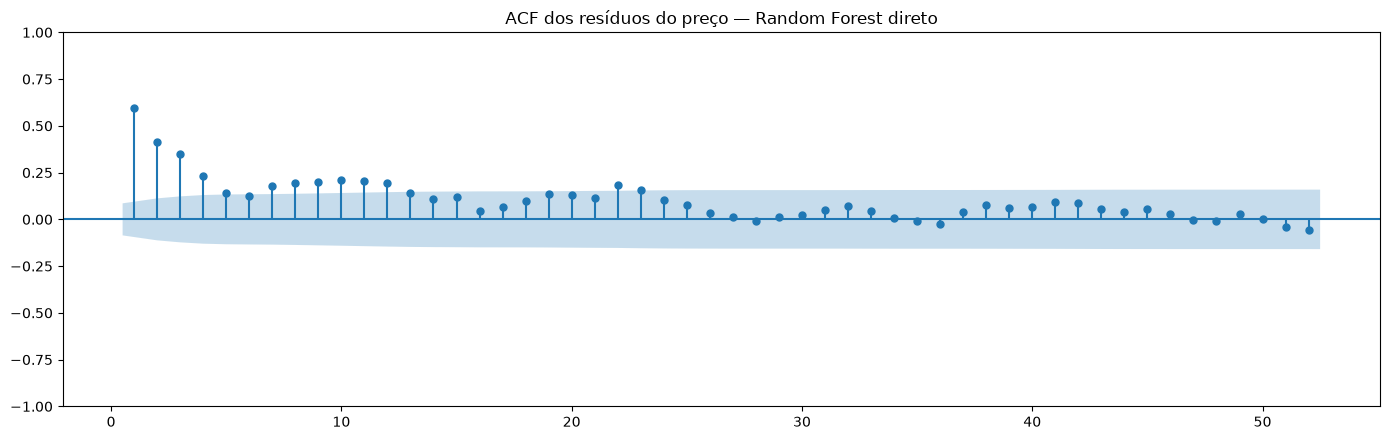

,lb_stat,lb_pvalue,rejeita_ruido_branco_5pct
1,187.767506,9.764521e-43,True
4,372.165968,2.865637e-79,True
13,528.184642,1.498664e-104,True
26,620.050700,3.901364e-114,True


In [14]:
fig, ax = plt.subplots(figsize=(14, 4.5))
plot_acf(residuals, lags=52, zero=False, ax=ax)
ax.set_title('ACF dos resíduos do preço — Random Forest direto')
plt.tight_layout(); plt.show()
ljung_box = acorr_ljungbox(residuals, lags=[1, 4, 13, 26], return_df=True)
ljung_box['rejeita_ruido_branco_5pct'] = ljung_box.lb_pvalue < .05
display(ljung_box)

## 13. Previsões diretas do preço do ouro

Tabela e gráfico das previsões diretas, sempre fora da amostra.

Previsão direta mais recente disponível no teste:


,2343
data_origem,2014-04-04 00:00:00
data_prevista,2014-04-11 00:00:00
preco_na_origem,1293.5
preco_real,1309.75
preco_previsto_rf_direto,1304.824445
preco_previsto_persistencia,1293.5
tem_cotacao_nova,1
erro_rf,4.925555
erro_absoluto_rf,4.925555


Últimas 20 previsões diretas:


,data_origem,data_prevista,preco_na_origem,preco_real,preco_previsto_rf_direto,preco_previsto_persistencia,tem_cotacao_nova,erro_rf,erro_absoluto_rf
2324,2013-11-22,2013-11-29,1241.75,1245.25,1259.229883,1241.75,1,-13.979883,13.979883
2325,2013-11-29,2013-12-06,1245.25,1230.75,1256.964061,1245.25,1,-26.214061,26.214061
2326,2013-12-06,2013-12-13,1230.75,1222.75,1247.757386,1230.75,1,-25.007386,25.007386
2327,2013-12-13,2013-12-20,1222.75,1195.00,1236.412298,1222.75,1,-41.412298,41.412298
2328,2013-12-20,2013-12-27,1195.00,1192.75,1220.381523,1195.00,1,-27.631523,27.631523
2329,2013-12-27,2014-01-03,1192.75,1192.75,1214.711550,1192.75,0,-21.961550,21.961550
2330,2014-01-03,2014-01-10,1192.75,1232.25,1214.447894,1192.75,1,17.802106,17.802106
2331,2014-01-10,2014-01-17,1232.25,1241.00,1223.082565,1232.25,1,17.917435,17.917435
2332,2014-01-17,2014-01-24,1241.00,1259.25,1228.013217,1241.00,1,31.236783,31.236783
2333,2014-01-24,2014-01-31,1259.25,1246.50,1257.237901,1259.25,1,-10.737901,10.737901


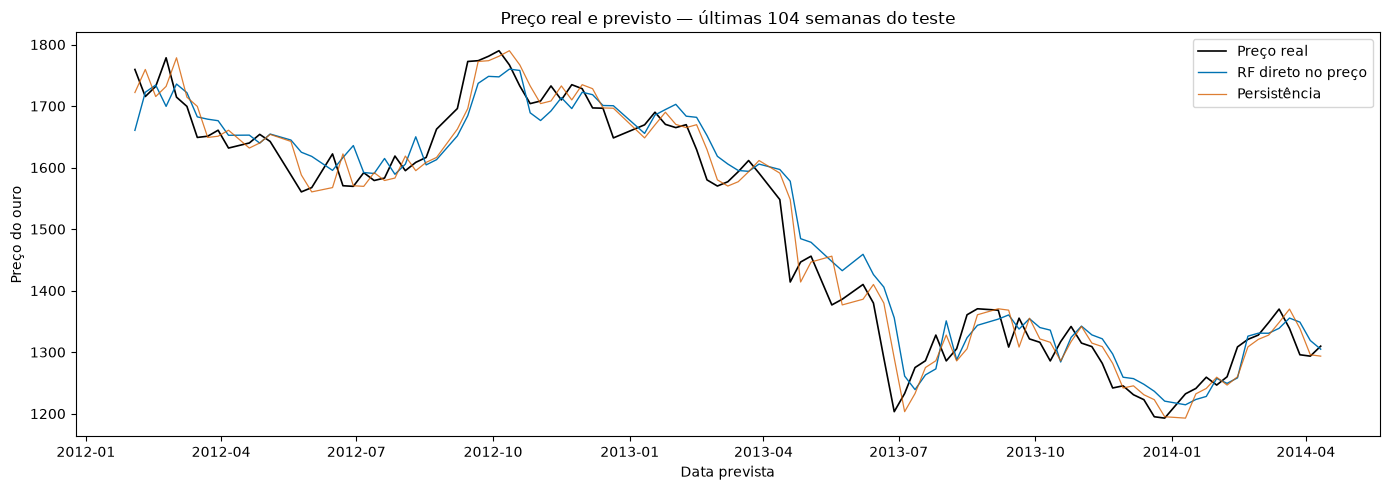

In [15]:
price_forecasts = predictions[[
    'DATE', 'target_date', 'price_t', 'target_price_t_plus_1',
    'price_pred_rf', 'price_pred_persistence', 'target_has_new_quote',
]].rename(columns={
    'DATE': 'data_origem',
    'target_date': 'data_prevista',
    'price_t': 'preco_na_origem',
    'target_price_t_plus_1': 'preco_real',
    'price_pred_rf': 'preco_previsto_rf_direto',
    'price_pred_persistence': 'preco_previsto_persistencia',
    'target_has_new_quote': 'tem_cotacao_nova',
})
price_forecasts['erro_rf'] = price_forecasts.preco_real - price_forecasts.preco_previsto_rf_direto
price_forecasts['erro_absoluto_rf'] = price_forecasts.erro_rf.abs()

print('Previsão direta mais recente disponível no teste:')
display(price_forecasts.tail(1).T)
print('Últimas 20 previsões diretas:')
display(price_forecasts.tail(20))

plot_data = price_forecasts.loc[price_forecasts.tem_cotacao_nova.eq(1)].tail(104)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_data.data_prevista, plot_data.preco_real, label='Preço real', color='black', lw=1.2)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_rf_direto,
        label='RF direto no preço', color='#0072b2', lw=1)
ax.plot(plot_data.data_prevista, plot_data.preco_previsto_persistencia,
        label='Persistência', color='#d55e00', lw=.9, alpha=.8)
ax.set(title='Preço real e previsto — últimas 104 semanas do teste',
       xlabel='Data prevista', ylabel='Preço do ouro')
ax.legend()
plt.tight_layout(); plt.show()